In [ ]:
pip install gdown

In [ ]:
# Download the zip file from Google Drive
import gdown
import os

# link: https://drive.google.com/file/d/1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL/view?usp=sharing
file_id = '1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL'
output_filename = 'archive.zip'

gdown.download(id=file_id, output=output_filename, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL
From (redirected): https://drive.google.com/uc?id=1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL&confirm=t&uuid=befa361b-55ae-4049-8001-6ef7a404504c
To: /content/archive.zip
100%|██████████| 1.27G/1.27G [00:27<00:00, 45.9MB/s]


'archive.zip'

In [ ]:
# Extract the contents of the zip file
import zipfile

if os.path.exists(output_filename):
    with zipfile.ZipFile(output_filename, 'r') as zip_ref:
        zip_ref.extractall('.') # Extract to the current directory
    print(f"Successfully extracted '{output_filename}'")
    # Optionally, remove the zip file after extraction
    # os.remove(output_filename)
else:
    print(f"Error: The file '{output_filename}' was not found.")

Successfully extracted 'archive.zip'


In [ ]:
# List the contents of the current directory to see extracted files
print("Contents of the current directory after extraction:")
print(os.listdir('.'))

Contents of the current directory after extraction:
['.config', 'archive.zip', 'train', 'test', 'sample_data']


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform=transforms.Compose([
    transforms.Resize((110, 100)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

full_dataset = datasets.ImageFolder(root='train', transform=transform)

In [ ]:
# Split the full_dataset into training and validation sets
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

In [ ]:
# changed batch size
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)


In [ ]:
num_classes = len(full_dataset.classes)
print(f"Number of classes in the dataset: {num_classes}")

Number of classes in the dataset: 4


In [ ]:
from collections import Counter

# Count classes in train_dataset
train_class_counts = Counter()
for _, labels in train_loader:
    train_class_counts.update(labels.cpu().numpy())

print("Number of images per class in Training Set:")
for class_idx, count in sorted(train_class_counts.items()):
    class_name = full_dataset.classes[class_idx]
    print(f"  Class {class_name} (ID: {class_idx}): {count} images")

# Count classes in val_dataset
val_class_counts = Counter()
for _, labels in val_loader:
    val_class_counts.update(labels.cpu().numpy())

print("\nNumber of images per class in Validation Set:")
for class_idx, count in sorted(val_class_counts.items()):
    class_name = full_dataset.classes[class_idx]
    print(f"  Class {class_name} (ID: {class_idx}): {count} images")

Number of images per class in Training Set:
  Class broadleaf (ID: 0): 671 images
  Class grass (ID: 1): 1997 images
  Class soil (ID: 2): 1810 images
  Class soybean (ID: 3): 4109 images

Number of images per class in Validation Set:
  Class broadleaf (ID: 0): 162 images
  Class grass (ID: 1): 467 images
  Class soil (ID: 2): 464 images
  Class soybean (ID: 3): 1054 images


In [ ]:
test_dataset = datasets.ImageFolder(root='test', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

# Count classes in test_dataset
test_class_counts = Counter()
for _, labels in test_loader:
    test_class_counts.update(labels.cpu().numpy())

print("Number of images per class in Test Set:")
for class_idx, count in sorted(test_class_counts.items()):
    class_name = full_dataset.classes[class_idx]
    print(f"  Class {class_name} (ID: {class_idx}): {count} images")

Number of images per class in Test Set:
  Class broadleaf (ID: 0): 358 images
  Class grass (ID: 1): 1056 images
  Class soil (ID: 2): 975 images
  Class soybean (ID: 3): 2213 images


In [ ]:
def train_model(model, train_loader, val_loader, epochs=10):
    history = {'train_loss': [], 'val_loss': [], 'val_accuracy': [], 'train_accuracy': []}
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted_train = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted_train == labels).sum().item()

        # Validation
        model.eval()
        val_loss = 0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted_val = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted_val == labels).sum().item()

        epoch_train_loss = train_loss/len(train_loader)
        epoch_train_accuracy = 100 * correct_train / total_train
        epoch_val_loss = val_loss/len(val_loader)
        epoch_val_accuracy = 100 * correct_val / total_val

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_accuracy)
        history['train_accuracy'].append(epoch_train_accuracy)

        # Step the scheduler based on validation loss
        scheduler.step(epoch_val_loss)

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {epoch_train_loss:.4f}")
        print(f"Train Accuracy: {epoch_train_accuracy:.2f}%")
        print(f"Val Loss: {epoch_val_loss:.4f}")
        print(f"Val Accuracy: {epoch_val_accuracy:.2f}%\n")
    return history

In [ ]:
def evaluate_model(model, test_loader):
    model.eval()

    test_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total

    print(f"Test Loss: {test_loss/len(test_loader):.4f}")
    print(f"Test Accuracy: {accuracy:.2f}%")

    return all_preds, all_labels

model 2

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN2(nn.Module):
    def __init__(self, num_classes=4):
        super(CustomCNN2, self).__init__()

        self.conv1 = nn.Conv2d(3, 256, 3)
        self.conv2 = nn.Conv2d(256, 128, 3)
        self.conv3 = nn.Conv2d(128, 64, 3)
        self.conv4 = nn.Conv2d(64, 32, 3)
        self.conv5 = nn.Conv2d(32, 8, 3)

        self.pool = nn.MaxPool2d(2, 2)

        # ❗ CORRECT input size
        self.fc1 = nn.Linear(8, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        x = self.pool(F.relu(self.conv5(x)))

        x = x.view(x.size(0), -1)  # → 8

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [ ]:
device = torch.device("cuda")

model2 = CustomCNN2(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=0.0005)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

In [ ]:
total_params = sum(p.numel() for p in model2.parameters())
print("Total parameters:", total_params)

Total parameters: 414956


In [ ]:
history2=train_model(model2, train_loader, val_loader, epochs=15)

Epoch [1/15]
Train Loss: 0.4823
Train Accuracy: 81.31%
Val Loss: 0.2843
Val Accuracy: 88.64%

Epoch [2/15]
Train Loss: 0.3410
Train Accuracy: 86.68%
Val Loss: 0.2858
Val Accuracy: 88.82%

Epoch [3/15]
Train Loss: 0.3145
Train Accuracy: 87.63%
Val Loss: 0.2632
Val Accuracy: 88.45%

Epoch [4/15]
Train Loss: 0.2968
Train Accuracy: 88.06%
Val Loss: 0.2633
Val Accuracy: 89.01%

Epoch [5/15]
Train Loss: 0.2614
Train Accuracy: 88.55%
Val Loss: 0.2534
Val Accuracy: 89.24%

Epoch [6/15]
Train Loss: 0.2389
Train Accuracy: 90.40%
Val Loss: 0.1799
Val Accuracy: 92.41%

Epoch [7/15]
Train Loss: 0.1917
Train Accuracy: 93.12%
Val Loss: 0.1817
Val Accuracy: 93.95%

Epoch [8/15]
Train Loss: 0.1498
Train Accuracy: 95.20%
Val Loss: 0.2020
Val Accuracy: 93.06%

Epoch [9/15]
Train Loss: 0.1291
Train Accuracy: 95.67%
Val Loss: 0.1420
Val Accuracy: 96.18%

Epoch [10/15]
Train Loss: 0.1034
Train Accuracy: 96.51%
Val Loss: 0.1559
Val Accuracy: 95.30%

Epoch [11/15]
Train Loss: 0.0942
Train Accuracy: 97.03%
Val

In [ ]:
history2['train_accuracy'][:-1]

[81.30895539769419,
 86.67753580994527,
 87.63246768370793,
 88.0633515779667,
 88.55246302550367,
 90.40409921975079,
 93.11750320251544,
 95.20204960987539,
 95.66787003610108,
 96.50634680330732,
 97.03039478281123,
 97.2167229533015,
 97.2167229533015,
 97.6010248049377]

In [ ]:
preds, labels = evaluate_model(model2, test_loader)

Test Loss: 0.0780
Test Accuracy: 97.83%


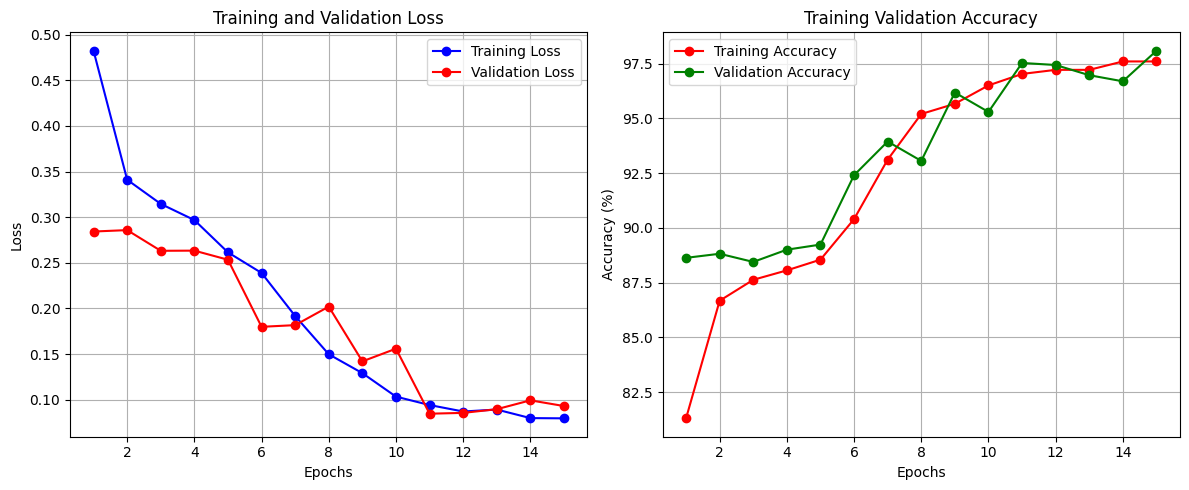

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history2['train_loss']) + 1)

plt.figure(figsize=(12, 5))

# Plotting Training and Validation Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(epochs, history2['train_loss'], 'bo-', label='Training Loss')
plt.plot(epochs, history2['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting Validation Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(epochs, history2['train_accuracy'], 'ro-', label='Training Accuracy')
plt.plot(epochs, history2['val_accuracy'], 'go-', label='Validation Accuracy')
plt.title('Training Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# from sklearn.metrics import classification_report

# print(classification_report(labels, preds, target_names=test_dataset.classes))

latency

In [ ]:
import time

def measure_latency(model, loader, device, num_batches=2):
    model.eval()
    model.to(device)

    total_time = 0
    count = 0

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)

            start = time.time()
            outputs = model(images)
            end = time.time()

            total_time += (end - start)
            count += 1

            if count >= num_batches:
                break

    avg_latency = total_time / count
    print(f"Average Latency per batch: {avg_latency:.6f} seconds")
    return avg_latency

In [ ]:
measure_latency(model2, test_loader, device)

Average Latency per batch: 0.000844 seconds


0.0008440017700195312

RAM usage

In [ ]:
import psutil
import os

def measure_ram():
    process = psutil.Process(os.getpid())
    mem = process.memory_info().rss / 1024**3  # GB
    print(f"RAM Usage: {mem:.4f} GB")
    return mem

In [ ]:
model2.to("cpu")
model2.eval()

images, _ = next(iter(test_loader))
images = images.to("cpu")

measure_ram()
with torch.no_grad():
    outputs = model2(images)
measure_ram()

RAM Usage: 1.2630 GB
RAM Usage: 1.3059 GB


1.3059310913085938

In [ ]:
def get_model_size(model):
    torch.save(model.state_dict(), "temp.p")
    size = os.path.getsize("temp.p") / 1024**2
    print(f"Model size: {size:.2f} MB")
    os.remove("temp.p")
    return size

In [ ]:
get_model_size(model2)

Model size: 1.59 MB


1.587449073791504

Quantization

In [ ]:
import torch.quantization

quantized_model = torch.quantization.quantize_dynamic(
    model2,
    {nn.Linear},  # only linear layers quantized
    dtype=torch.qint8
)

/tmp/ipykernel_2291/2182927698.py:3: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


In [ ]:
device = torch.device("cpu")
model2.to(device)
quantized_model.to(device)

CustomCNN2(
  (conv1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv5): Conv2d(32, 8, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): DynamicQuantizedLinear(in_features=8, out_features=128, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (fc2): DynamicQuantizedLinear(in_features=128, out_features=128, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (fc3): DynamicQuantizedLinear(in_features=128, out_features=4, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
)

In [ ]:
quantized_model.to("cpu")
quantized_model.eval()
images = images.to("cpu")
measure_ram()
with torch.no_grad():
    outputs = quantized_model(images)
measure_ram()

RAM Usage: 1.3184 GB
RAM Usage: 1.3036 GB


1.3035659790039062

In [ ]:
preds,labels=evaluate_model(quantized_model, test_loader)

Test Loss: 0.0744
Test Accuracy: 97.70%


Measurements

In [ ]:
print("FP32 Model:")
measure_latency(model2, test_loader, device)
get_model_size(model2)

print("\nINT8 Quantized Model:")
measure_latency(quantized_model, test_loader, device)
get_model_size(quantized_model)

FP32 Model:
Average Latency per batch: 0.080330 seconds
Model size: 1.59 MB

INT8 Quantized Model:
Average Latency per batch: 0.082658 seconds
Model size: 1.54 MB


1.5380373001098633

Save the model

In [ ]:
torch.save(model2.state_dict(), "Custommodel2_fp32.pth")

In [ ]:
torch.save(quantized_model.state_dict(), "Custommodel2_int8.pth")

In [ ]:
from google.colab import files

files.download("Custommodel2_fp32.pth")
files.download("Custommodel2_int8.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>